In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()
# Then read it normally
# df = pd.read_csv('filename.csv')

/tmp/ipykernel_271/1667530259.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['predicted_price'] = model.predict(val_df[['town_lag_1']])


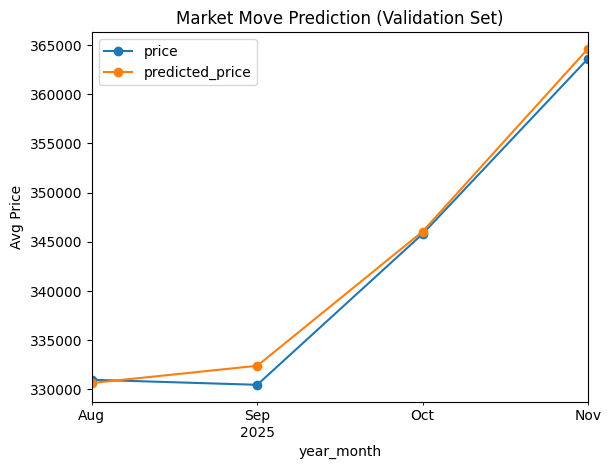

Validation Results:
                    price  predicted_price
year_month                                
2025-08     330927.682565    330596.830293
2025-09     330412.987875    332351.416565
2025-10     345783.054666    346025.596155
2025-11     363633.092704    364641.235822


In [1]:

# --- STEP 1: GENERATE LOGICAL SYNTHETIC DATA ---
np.random.seed(42)
months = 35
records_per_month = 100
total_records = months * records_per_month

dates = pd.date_range(start='2023-01-01', periods=months, freq='MS').tolist() * records_per_month
towns = ['London', 'Manchester', 'Bristol']
streets = ['High St', 'Main Rd', 'Park Ave', 'Station Rd']

data = {
    'date': sorted(dates),
    'price': [],
    'town': np.random.choice(towns, total_records),
    'street': np.random.choice(streets, total_records)
}

# Add logical price logic: Base + Trend + Seasonality + Noise
for i, date in enumerate(data['date']):
    base = 250000
    month_idx = (date.year - 2023) * 12 + (date.month - 1)
    trend = month_idx * 1500  # Prices go up £1500 every month
    seasonality = np.sin(date.month * (2 * np.pi / 12)) * 10000 # Summer peak
    noise = np.random.normal(0, 5000)

    # Towns have different "weights"
    town_weight = 1.5 if data['town'][i] == 'London' else 1.0
    data['price'].append((base + trend + seasonality + noise) * town_weight)

df = pd.DataFrame(data)

# --- STEP 2: FEATURE ENGINEERING (Market Dynamics) ---
df['year_month'] = df['date'].dt.to_period('M')

# Calculate the "Surrounding Market Move" (Town Average)
town_market = df.groupby(['town', 'year_month'])['price'].mean().rename('town_avg').reset_index()
df = df.merge(town_market, on=['town', 'year_month'], how='left')

# Create Lags (The "Past Trend" feature)
df['town_lag_1'] = df.groupby('town')['town_avg'].shift(1)
df = df.dropna()

# --- STEP 3: TRAIN/TEST/VALIDATE SPLIT ---
all_months = sorted(df['year_month'].unique())
train_df = df[df['year_month'].isin(all_months[:30])]
test_df = df[df['year_month'] == all_months[30]]
val_df = df[df['year_month'].isin(all_months[31:])]

# --- STEP 4: MODELING ---
model = GradientBoostingRegressor()
model.fit(train_df[['town_lag_1']], train_df['price'])

# Predict
val_df['predicted_price'] = model.predict(val_df[['town_lag_1']])

# --- STEP 5: VISUALIZE ---
comparison = val_df.groupby('year_month')[['price', 'predicted_price']].mean()
comparison.plot(kind='line', marker='o', title="Market Move Prediction (Validation Set)")
plt.ylabel("Avg Price")
plt.show()

print("Validation Results:")
print(comparison)

In [ ]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. LOAD & CLEAN (Lite for Kaggle/Colab)
# Assuming df is loaded with ['price', 'date', 'town', 'type']
def preprocess_data(df):
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')

    # Create Time Index (Linear Trend)
    df['time_index'] = (df['date'] - df['date'].min()).dt.days
    df['month'] = df['date'].dt.month

    # Target Encoding for 'Town' (Crucial for Geography)
    town_means = df.groupby('town')['price'].mean()
    df['town_encoded'] = df['town'].map(town_means)

    # Create Lag (Market Momentum)
    df['market_lag_1'] = df['town_encoded'].shift(1)

    return df.dropna()

df_clean = preprocess_data(df)

# 2. FEATURE SELECTION
features = ['time_index', 'month', 'town_encoded', 'market_lag_1']
X = df_clean[features]
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. MLOPS INTEGRATION (MLflow)
mlflow.set_experiment("House_Price_Forecasting")

with mlflow.start_run():
    # Define Hyperparameters
    params = {"n_estimators": 100, "max_depth": 10, "random_state": 42}
    mlflow.log_params(params)

    # Train Model
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    # Predict & Evaluate
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    # Log Metrics
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2_score", r2)

    # Log Feature Importance
    importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    print("Feature Contribution:\n", importance)

    # Save Model
    mlflow.sklearn.log_model(model, "random_forest_housing_model")

    print(f"Model Tracked. MAE: {mae}")

# 4. QUANTIFYING FUTURE CHANGE
# To see future impact, manually increase 'time_index' by 365 days
# and see how much the predicted price jumps compared to 'town_encoded'.


MLFLOW approh for experiment tracking with Parameter and Hyperperamters

In [8]:
!pip install mlflow
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. LOAD & CLEAN (Lite for Kaggle/Colab)
# Assuming df is loaded with ['price', 'date', 'town', 'type']
def preprocess_data(df):
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')

    # Create Time Index (Linear Trend)
    df['time_index'] = (df['date'] - df['date'].min()).dt.days
    df['month'] = df['date'].dt.month

    # Target Encoding for 'Town' (Crucial for Geography)
    town_means = df.groupby('town')['price'].mean()
    df['town_encoded'] = df['town'].map(town_means)

    # Create Lag (Market Momentum)
    df['market_lag_1'] = df['town_encoded'].shift(1)

    return df.dropna()

df_clean = preprocess_data(df)

# 2. FEATURE SELECTION
features = ['time_index', 'month', 'town_encoded', 'market_lag_1']
X = df_clean[features]
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. MLOPS INTEGRATION (MLflow)
mlflow.set_experiment("House_Price_Forecasting")

with mlflow.start_run():
    # Define Hyperparameters
    params = {"n_estimators": 100, "max_depth": 10, "random_state": 42}
    mlflow.log_params(params)

    # Train Model
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    # Predict & Evaluate
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    # Log Metrics
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2_score", r2)

    # Log Feature Importance
    importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    print("Feature Contribution:\n", importance)

    # Save Model
    mlflow.sklearn.log_model(model, "random_forest_housing_model")

    print(f"Model Tracked. MAE: {mae}")

# 4. QUANTIFYING FUTURE CHANGE
# To see future impact, manually increase 'time_index' by 365 days
# and see how much the predicted price jumps compared to 'town_encoded'.


2026/03/15 16:25:07 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/15 16:25:07 INFO mlflow.store.db.utils: Updating database tables
2026/03/15 16:25:09 INFO mlflow.tracking.fluent: Experiment with name 'House_Price_Forecasting' does not exist. Creating a new experiment.
2026/03/15 16:25:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 16:25:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Feature Contribution:
 town_encoded    0.937184
time_index      0.059034
month           0.003147
market_lag_1    0.000636
dtype: float64
Model Tracked. MAE: 9024.150149493724
